
Stage 1: Training solution (beta frozen)...

Stage 2: Training inverse using 'standard' weighting...
Iter    0 | Total Loss 9.682e-03 | k 50.050 | lambda 1.000
Iter  200 | Total Loss 9.419e-03 | k 52.224 | lambda 1.000
Iter  400 | Total Loss 9.072e-03 | k 55.763 | lambda 1.000
Iter  600 | Total Loss 8.775e-03 | k 59.782 | lambda 1.000
Iter  800 | Total Loss 8.554e-03 | k 63.836 | lambda 1.000
Iter 1000 | Total Loss 8.347e-03 | k 67.723 | lambda 1.000
Iter 1200 | Total Loss 8.205e-03 | k 71.330 | lambda 1.000
Iter 1400 | Total Loss 8.856e-03 | k 74.511 | lambda 1.000
Iter 1600 | Total Loss 8.160e-03 | k 77.615 | lambda 1.000
Iter 1800 | Total Loss 8.076e-03 | k 80.539 | lambda 1.000

Refining with L-BFGS...

Recovered k: 138.52411 (True: 100.0)
Recovered beta: 0.36095 (True: 0.5)


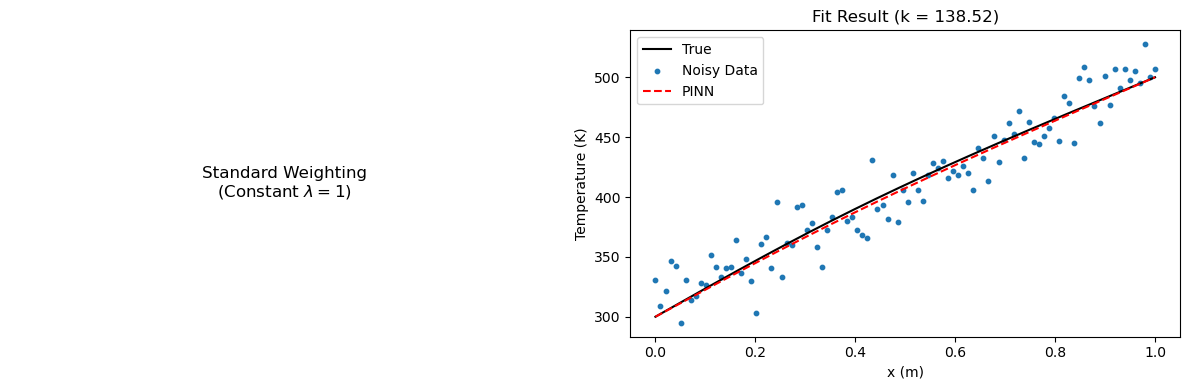

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ==========================================
# CONFIGURATION: Choose your weighting scheme
# Options: 'standard-well scaled', 'annealing', 'ntk'
# ==========================================
WEIGHTING_SCHEME = 'standard' 

# -----------------------------
# 1. Physical parameters & True Solution
# -----------------------------
k_true = 100.0
Q0 = 10000.0
L = 1
T_left = 300.0
T_right = 500.0
dT = T_right - T_left
beta_true = Q0 * L**2 / (k_true * dT)

def theta_true(x_star):
    return (
        x_star
        + (beta_true / (np.pi**2)) * np.sin(np.pi * x_star)
        + 0.3 * (beta_true / (4*np.pi**2)) * np.sin(2*np.pi * x_star)
    )

def T_true(x):
    return T_left + dT * theta_true(x / L)

# -----------------------------
# 2. Data + Noise Setup
# -----------------------------
x_data = np.linspace(0, L, 100)
theta_clean = theta_true(x_data / L)
noise_amp = 0.3
theta_noisy = theta_clean + noise_amp * np.std(theta_clean) * np.random.randn(len(x_data))

x_data_t = torch.tensor(x_data, dtype=torch.float32).view(-1,1)
theta_data_t = torch.tensor(theta_noisy, dtype=torch.float32).view(-1,1)

x_f = torch.linspace(0, L, 200).view(-1,1)
x_f.requires_grad = True

# -----------------------------
# 3. PINN Model Definition
# -----------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.log_beta = nn.Parameter(torch.tensor([np.log(1.0)]))

    def forward(self, x):
        x_star = x / L
        return x_star + x_star*(1-x_star)*self.net(x)

    def get_beta(self):
        return torch.exp(self.log_beta)

    def get_k(self):
        beta = self.get_beta()
        return Q0 * L**2 / (beta * dT)

model = PINN()

# -----------------------------
# 4. Unsummed Loss Function
# -----------------------------
def get_unsummed_losses():
    # 1. Data loss
    theta_pred = model(x_data_t)
    loss_data = torch.mean((theta_pred - theta_data_t)**2)

    # 2. Physics loss
    theta = model(x_f)
    g = torch.autograd.grad(theta, x_f, torch.ones_like(theta), create_graph=True)[0]
    g2 = torch.autograd.grad(g, x_f, torch.ones_like(g), create_graph=True)[0]

    beta = model.get_beta()
    forcing = torch.sin(np.pi * x_f / L) + 0.3 * torch.sin(2 * np.pi * x_f / L)
    
    scale = beta.detach() + 1e-6 
    res = (g2 + (beta / L**2) * forcing) / scale
    loss_phys = torch.mean(res**2)

    # 3. Regularization
    loss_reg = 1e-6 * model.log_beta**2

    return loss_data, loss_phys, loss_reg

# -----------------------------
# 5. Stage 1: Train solution only (beta frozen)
# -----------------------------
print("\nStage 1: Training solution (beta frozen)...")
model.log_beta.requires_grad = False
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in range(1000):
    opt.zero_grad()
    ld, lp, lr = get_unsummed_losses()
    loss = ld + lp + lr
    loss.backward()
    opt.step()

# -----------------------------
# 6. Stage 2: Inverse Problem with Adaptive Weights
# -----------------------------
print(f"\nStage 2: Training inverse using '{WEIGHTING_SCHEME}' weighting...")
model.log_beta.requires_grad = True
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Tracking variables for the dynamic weight
lambda_phys = 1.0 
alpha = 0.9 # Only used for 'annealing'
lambda_history = []

for i in range(2000):
    opt.zero_grad()
    loss_data, loss_phys, loss_reg = get_unsummed_losses()

    if WEIGHTING_SCHEME == 'standard':
        total_loss = loss_data + loss_phys + loss_reg
        total_loss.backward()
        opt.step()

    elif WEIGHTING_SCHEME == 'annealing':
        # Get data gradients
        opt.zero_grad()
        loss_data.backward(retain_graph=True)
        grad_data = torch.cat([p.grad.view(-1) for p in model.net.parameters() if p.grad is not None])
        
        # Get physics gradients
        opt.zero_grad()
        loss_phys.backward(retain_graph=True)
        grad_phys = torch.cat([p.grad.view(-1) for p in model.net.parameters() if p.grad is not None])

        with torch.no_grad():
            max_grad_data = torch.max(torch.abs(grad_data))
            mean_grad_phys = torch.mean(torch.abs(grad_phys))
            lambda_hat = max_grad_data / (mean_grad_phys + 1e-8)
            lambda_phys = (1.0 - alpha) * lambda_phys + alpha * lambda_hat.item()

        opt.zero_grad()
        total_loss = loss_data + lambda_phys * loss_phys + loss_reg
        total_loss.backward()
        opt.step()

    elif WEIGHTING_SCHEME == 'ntk':
        # Get NTK trace for data
        opt.zero_grad()
        loss_data.backward(retain_graph=True)
        ntk_data_trace = sum(torch.sum(p.grad ** 2) for p in model.net.parameters() if p.grad is not None)

        # Get NTK trace for physics
        opt.zero_grad()
        loss_phys.backward(retain_graph=True)
        ntk_phys_trace = sum(torch.sum(p.grad ** 2) for p in model.net.parameters() if p.grad is not None)

        with torch.no_grad():
            lambda_phys = (ntk_data_trace / (ntk_phys_trace + 1e-8)).item()

        opt.zero_grad()
        total_loss = loss_data + lambda_phys * loss_phys + loss_reg
        total_loss.backward()
        opt.step()
        
    lambda_history.append(lambda_phys)

    if i % 200 == 0:
        print(f"Iter {i:4d} | Total Loss {total_loss.item():.3e} | k {model.get_k().item():.3f} | lambda {lambda_phys:.3f}")

# -----------------------------
# 7. L-BFGS refinement
# -----------------------------
print("\nRefining with L-BFGS...")
# Standard sum is used here for stability, as adaptive weights in L-BFGS closures get complicated
optimizer = torch.optim.LBFGS(model.parameters(), max_iter=500)

def closure():
    optimizer.zero_grad()
    ld, lp, lr = get_unsummed_losses()
    # Lock in the final lambda_phys value found by Adam
    loss = ld + (lambda_phys * lp) + lr 
    loss.backward()
    return loss

optimizer.step(closure)

# -----------------------------
# 8. Results & Plotting
# -----------------------------
k_pred = model.get_k().item()
beta_pred = model.get_beta().item()

print(f"\nRecovered k: {k_pred:.5f} (True: {k_true})")
print(f"Recovered beta: {beta_pred:.5f} (True: {beta_true})")

# Plot Lambda evolution and final curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

if WEIGHTING_SCHEME != 'standard':
    ax1.plot(lambda_history)
    ax1.set_title(f"$\lambda_{{phys}}$ Evolution ({WEIGHTING_SCHEME})")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Weight")
    ax1.set_yscale('log')
else:
    ax1.text(0.5, 0.5, 'Standard Weighting\n(Constant $\lambda=1$)', 
             ha='center', va='center', fontsize=12)
    ax1.axis('off')

x_plot = np.linspace(0, L, 200)
T_true_plot = T_true(x_plot)
with torch.no_grad():
    theta_pred_plot = model(torch.tensor(x_plot, dtype=torch.float32).view(-1,1)).numpy()
T_pred_plot = T_left + dT * theta_pred_plot

ax2.plot(x_plot, T_true_plot, 'k-', label="True")
ax2.scatter(x_data, T_left + dT * theta_noisy, s=10, label="Noisy Data")
ax2.plot(x_plot, T_pred_plot, 'r--', label="PINN")
ax2.legend()
ax2.set_title(f"Fit Result (k = {k_pred:.2f})")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("Temperature (K)")

plt.tight_layout()
plt.show()